In [ ]:
import os
import json
import joblib
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
)

import matplotlib.pyplot as plt
import seaborn as sns

# ----------------- PATHS -----------------
BASE_DIR = "/content/drive/MyDrive/AML_Project_v2"

# FULL IBM dataset (edit this if needed)
FULL_DATA_PATH = "/content/drive/MyDrive/HI-Small_Trans.csv"  # <--- CHANGE if your path is different

# AE artifacts
PREPROC_CONFIG_JSON = os.path.join(BASE_DIR, "ae_preproc_config_0p2.json")
SCALER_PKL          = os.path.join(BASE_DIR, "ae_num_scaler_0p2.pkl")
AE_MODEL_PATH       = os.path.join(BASE_DIR, "autoencoder_v2_0p2.pth")

# GNN / MV embeddings (MC-Dropout version)
MV_EMB_MC_NPY       = os.path.join(BASE_DIR, "node_embeddings_mv_sage_mc_0p2.npy")
ACC_MAP_PKL         = os.path.join(BASE_DIR, "account_index_map_0p2.pkl")
ACC_UNCERT_NPY      = os.path.join(BASE_DIR, "account_uncertainty_mc_0p2.npy")
ACC_UNSTABLE_NPY    = os.path.join(BASE_DIR, "account_unstable_mask_mc_0p2.npy")

# XGB v5 model + schema
XGB_MODEL_PKL       = os.path.join(BASE_DIR, "xgboost_v5_ae_mvgnn_mc_0p2.pkl")
FUSION_SCHEMA_JSON  = os.path.join(BASE_DIR, "xgb_fusion_schema_mc_0p2.json")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("BASE_DIR:", BASE_DIR)
print("FULL_DATA_PATH:", FULL_DATA_PATH)


BASE_DIR: /content/drive/MyDrive/AML_Project_v2
FULL_DATA_PATH: /content/drive/MyDrive/HI-Small_Trans.csv


In [ ]:
# Load AE preprocessing config
with open(PREPROC_CONFIG_JSON, "r") as f:
    preproc_config = json.load(f)

LABEL_COL          = preproc_config["label_col"]
ACCOUNT_COL        = preproc_config["account_col"]
ID_COLS            = preproc_config["id_cols"]
NUM_COLS           = preproc_config["num_cols"]
ONEHOT_COLS        = preproc_config["onehot_cols"]
CAT_ONEHOT_BASE    = preproc_config["cat_onehot_base_cols"]

print("LABEL_COL      :", LABEL_COL)
print("ACCOUNT_COL    :", ACCOUNT_COL)
print("NUM_COLS       :", NUM_COLS)
print("CAT_ONEHOT_BASE:", CAT_ONEHOT_BASE)
print("ONEHOT_COLS len:", len(ONEHOT_COLS))

num_scaler = joblib.load(SCALER_PKL)
print("Scaler loaded ✓")

# GNN side
emb_mv_mc   = np.load(MV_EMB_MC_NPY)
account_to_idx = joblib.load(ACC_MAP_PKL)
uncert_acc  = np.load(ACC_UNCERT_NPY)
unstable_mask = np.load(ACC_UNSTABLE_NPY)

num_accounts, mv_dim = emb_mv_mc.shape
print("MV embedding shape:", emb_mv_mc.shape)

# XGBoost v5
xgb_model: XGBClassifier = joblib.load(XGB_MODEL_PKL)
with open(FUSION_SCHEMA_JSON, "r") as f:
    fusion_schema = json.load(f)

print("XGB model loaded ✓")
print("Schema loaded ✓")


LABEL_COL      : Is Laundering
ACCOUNT_COL    : Account
NUM_COLS       : ['Amount Received', 'Amount Paid', 'Amount_Diff', 'Amount_Ratio']
CAT_ONEHOT_BASE: ['Receiving Currency', 'Payment Currency', 'Payment Format']
ONEHOT_COLS len: 37
Scaler loaded ✓
MV embedding shape: (331899, 128)
XGB model loaded ✓
Schema loaded ✓


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

input_dim = len(NUM_COLS) + len(ONEHOT_COLS)
latent_dim = 64  # we used 64 in Stage A

class AEDataset(Dataset):
    def __init__(self, X):
        self.X = torch.tensor(X, dtype=torch.float32)
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        return self.X[idx]

class StrongAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),

            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z

ae_model = StrongAutoencoder(input_dim=input_dim, latent_dim=latent_dim).to(device)
ae_model.load_state_dict(torch.load(AE_MODEL_PATH, map_location=device))
ae_model.eval()
print("AE model loaded ✓")
print("AE input_dim:", input_dim, "latent_dim:", latent_dim)


Using device: cuda
AE model loaded ✓
AE input_dim: 41 latent_dim: 64


In [ ]:
def build_ae_input_from_raw(df_raw: pd.DataFrame) -> np.ndarray:
    df = df_raw.copy()

    # Ensure engineered features
    if "Amount_Diff" not in df.columns:
        df["Amount_Diff"] = df["Amount Paid"] - df["Amount Received"]
    if "Amount_Ratio" not in df.columns:
        df["Amount_Ratio"] = df["Amount Paid"] / (df["Amount Received"] + 1e-6)

    # Check numeric cols
    for col in NUM_COLS:
        if col not in df.columns:
            raise ValueError(f"Numeric column '{col}' missing even after engineering.")

    # 1) numeric
    df_num = df[NUM_COLS].astype(float)
    X_num = num_scaler.transform(df_num)

    # 2) categorical → one-hot
    df_cat = df[CAT_ONEHOT_BASE].astype(str)
    df_cat_dummies = pd.get_dummies(df_cat, columns=CAT_ONEHOT_BASE, drop_first=False)
    df_cat_dummies = df_cat_dummies.reindex(columns=ONEHOT_COLS, fill_value=0)
    X_cat = df_cat_dummies.values

    X_ae = np.hstack([X_num, X_cat])

    if X_ae.shape[1] != input_dim:
        raise ValueError(f"AE input dim mismatch: got {X_ae.shape[1]}, expected {input_dim}")
    return X_ae


In [ ]:
def compute_ae_features(X_ae: np.ndarray):
    ds = AEDataset(X_ae)
    loader = DataLoader(ds, batch_size=2048, shuffle=False)

    all_z, all_re = [], []
    ae_model.eval()
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            x_hat, z = ae_model(batch)
            mse = ((x_hat - batch) ** 2).mean(dim=1)
            all_z.append(z.cpu().numpy())
            all_re.append(mse.cpu().numpy())

    Z = np.concatenate(all_z, axis=0)
    recon = np.concatenate(all_re, axis=0)
    return Z, recon


In [ ]:
def build_fusion_features_mc(df_raw: pd.DataFrame):
    df = df_raw.copy()

    # 1) AE input & features
    X_ae = build_ae_input_from_raw(df)
    Z, recon = compute_ae_features(X_ae)

    ae_z_cols = [f"AE_z_{i}" for i in range(Z.shape[1])]
    df_feat = pd.DataFrame(Z, columns=ae_z_cols)
    df_feat["AE_recon_error"] = recon

    # attach basic cols for bookkeeping
    df_feat[ACCOUNT_COL] = df[ACCOUNT_COL].astype(str).values
    if LABEL_COL in df.columns:
        df_feat[LABEL_COL] = df[LABEL_COL].values
    for col in ID_COLS:
        if col in df.columns:
            df_feat[col] = df[col].values

    # 2) MV-GNN emb + uncertainty
    accounts = df_feat[ACCOUNT_COL].astype(str).values
    n = len(df_feat)

    mv_features = np.zeros((n, mv_dim), dtype=np.float32)
    uncert_feat  = np.zeros((n, 1), dtype=np.float32)
    unstable_feat = np.zeros((n, 1), dtype=np.float32)

    missing = 0
    for i, acc in enumerate(accounts):
        idx = account_to_idx.get(acc, None)
        if idx is not None:
            mv_features[i]   = emb_mv_mc[idx]
            uncert_feat[i,0] = uncert_acc[idx]
            unstable_feat[i,0] = unstable_mask[idx]
        else:
            missing += 1

    if missing > 0:
        print(f"Warning: {missing} rows have unseen accounts; MV emb = 0 for them.")

    X_ae_latent = df_feat[ae_z_cols].values
    X_ae_recon  = df_feat[["AE_recon_error"]].values

    X_fusion = np.hstack([X_ae_latent, X_ae_recon, mv_features, uncert_feat, unstable_feat])

    return X_fusion, df_feat


In [ ]:
def predict_transactions_mc(df_raw: pd.DataFrame, threshold: float = 0.5):
    X_fusion, df_feat = build_fusion_features_mc(df_raw)
    proba = xgb_model.predict_proba(X_fusion)[:, 1]
    preds = (proba >= threshold).astype(int)

    df_out = df_raw.copy()
    df_out["fraud_proba"] = proba
    df_out["fraud_pred"]  = preds
    return df_out

def evaluate_predictions(df_pred: pd.DataFrame, label_col=LABEL_COL, pred_col="fraud_pred", proba_col="fraud_proba"):
    if label_col not in df_pred.columns:
        raise ValueError(f"Ground truth column '{label_col}' not found!")

    y_true = df_pred[label_col].astype(int).values
    y_pred = df_pred[pred_col].astype(int).values
    y_proba = df_pred[proba_col].values

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_proba)

    print("===== METRICS (0.25% sample) =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1       : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")

    print("\n===== CONFUSION MATRIX =====")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Pred Normal", "Pred Fraud"],
                yticklabels=["True Normal", "True Fraud"])
    plt.title("Confusion Matrix (0.25% sample)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print("\n===== CLASSIFICATION REPORT =====")
    print(classification_report(y_true, y_pred, digits=4))

    # ROC curve
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr)
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (0.25% sample)")
    plt.show()


Full dataset shape: (5078345, 11)
          Timestamp  From Bank    Account  To Bank  Account.1  \
0  2022/09/01 00:20         10  8000EBD30       10  8000EBD30   
1  2022/09/01 00:20       3208  8000F4580        1  8000F5340   
2  2022/09/01 00:00       3209  8000F4670     3209  8000F4670   
3  2022/09/01 00:02         12  8000F5030       12  8000F5030   
4  2022/09/01 00:06         10  8000F5200       10  8000F5200   

   Amount Received Receiving Currency  Amount Paid Payment Currency  \
0          3697.34          US Dollar      3697.34        US Dollar   
1             0.01          US Dollar         0.01        US Dollar   
2         14675.57          US Dollar     14675.57        US Dollar   
3          2806.97          US Dollar      2806.97        US Dollar   
4         36682.97          US Dollar     36682.97        US Dollar   

  Payment Format  Is Laundering  
0   Reinvestment              0  
1         Cheque              0  
2   Reinvestment              0  
3   Reinvest

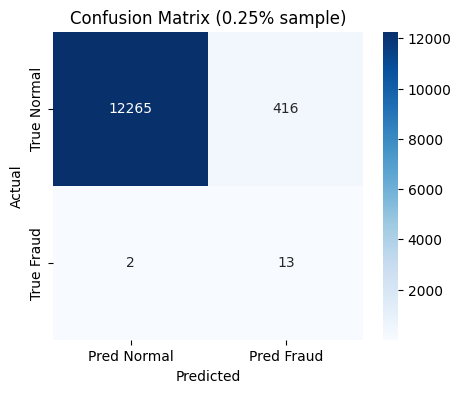


===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0     0.9998    0.9672    0.9832     12681
           1     0.0303    0.8667    0.0586        15

    accuracy                         0.9671     12696
   macro avg     0.5151    0.9169    0.5209     12696
weighted avg     0.9987    0.9671    0.9822     12696



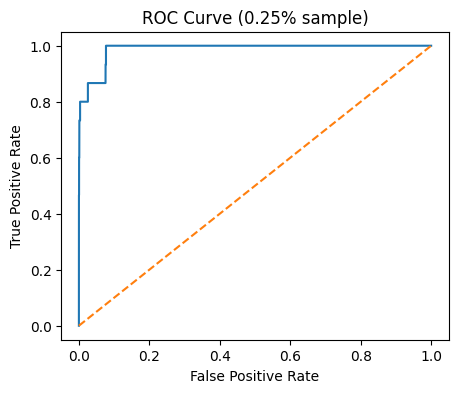

In [ ]:
# Load full IBM dataset
df_full = pd.read_csv(FULL_DATA_PATH)
print("Full dataset shape:", df_full.shape)
print(df_full.head())

# Sample 0.25% (0.0025 fraction) of the full dataset
sample_frac = 0.0025  # 0.25%
df_sample = df_full.sample(frac=sample_frac, random_state=SEED).reset_index(drop=True)
print(f"\nSampled shape (0.25%): {df_sample.shape}")

# Run MC pipeline
df_sample_pred = predict_transactions_mc(df_sample, threshold=0.5)

# Evaluate
evaluate_predictions(df_sample_pred)


In [ ]:
# Load full dataset
df_full = pd.read_csv(FULL_DATA_PATH)
print("Full dataset shape:", df_full.shape)

# Sample 25%
sample_frac = 0.25
df_25 = df_full.sample(frac=sample_frac, random_state=SEED).reset_index(drop=True)

print("25% sample shape:", df_25.shape)
df_25.head()


Full dataset shape: (5078345, 11)
25% sample shape: (1269586, 11)


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:29,117,80E50C3C0,40653,80FA8F490,4981.60,Swiss Franc,4981.60,Swiss Franc,Cheque,0
1,2022/09/01 13:28,10,8001C6CC0,22828,8010A7DF0,297.72,US Dollar,297.72,US Dollar,Cheque,0
2,2022/09/01 02:46,29191,80CAF3CE0,29191,80CAF3CE0,32.90,Yuan,32.90,Yuan,Reinvestment,0
3,2022/09/02 08:02,10,804DC2C20,14381,80597A020,194634.45,Rupee,194634.45,Rupee,Cheque,0
4,2022/09/09 18:01,16136,80A5EC8A0,16031,80C038E30,698940.91,US Dollar,698940.91,US Dollar,ACH,0


In [ ]:
def predict_large_dataset(df_raw, batch_size=50000, threshold=0.5):
    all_batches = []
    total = len(df_raw)
    print(f"Processing {total:,} rows in batches of {batch_size}...")

    for start in range(0, total, batch_size):
        end = min(start + batch_size, total)
        print(f"  → Batch {start:,} to {end:,}")

        batch = df_raw.iloc[start:end].copy()
        batch_pred = predict_transactions_mc(batch, threshold=threshold)
        all_batches.append(batch_pred)

    df_final = pd.concat(all_batches, axis=0).reset_index(drop=True)
    return df_final


In [ ]:
df_25_pred = predict_large_dataset(df_25, batch_size=50000, threshold=0.5)
print("25% prediction completed!")
df_25_pred.head()


Processing 1,269,586 rows in batches of 50000...
  → Batch 0 to 50,000
  → Batch 50,000 to 100,000
  → Batch 100,000 to 150,000
  → Batch 150,000 to 200,000
  → Batch 200,000 to 250,000
  → Batch 250,000 to 300,000
  → Batch 300,000 to 350,000
  → Batch 350,000 to 400,000
  → Batch 400,000 to 450,000
  → Batch 450,000 to 500,000
  → Batch 500,000 to 550,000
  → Batch 550,000 to 600,000
  → Batch 600,000 to 650,000
  → Batch 650,000 to 700,000
  → Batch 700,000 to 750,000
  → Batch 750,000 to 800,000
  → Batch 800,000 to 850,000
  → Batch 850,000 to 900,000
  → Batch 900,000 to 950,000
  → Batch 950,000 to 1,000,000
  → Batch 1,000,000 to 1,050,000
  → Batch 1,050,000 to 1,100,000
  → Batch 1,100,000 to 1,150,000
  → Batch 1,150,000 to 1,200,000
  → Batch 1,200,000 to 1,250,000
  → Batch 1,250,000 to 1,269,586
25% prediction completed!


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,fraud_proba,fraud_pred
0,2022/09/01 00:29,117,80E50C3C0,40653,80FA8F490,4981.60,Swiss Franc,4981.60,Swiss Franc,Cheque,0,0.000048,0
1,2022/09/01 13:28,10,8001C6CC0,22828,8010A7DF0,297.72,US Dollar,297.72,US Dollar,Cheque,0,0.000027,0
2,2022/09/01 02:46,29191,80CAF3CE0,29191,80CAF3CE0,32.90,Yuan,32.90,Yuan,Reinvestment,0,0.000030,0
3,2022/09/02 08:02,10,804DC2C20,14381,80597A020,194634.45,Rupee,194634.45,Rupee,Cheque,0,0.000117,0
4,2022/09/09 18:01,16136,80A5EC8A0,16031,80C038E30,698940.91,US Dollar,698940.91,US Dollar,ACH,0,0.089471,0


===== METRICS (0.25% sample) =====
Accuracy : 0.9685
Precision: 0.0252
Recall   : 0.7701
F1       : 0.0488
ROC-AUC  : 0.9543

===== CONFUSION MATRIX =====
[[1228589   39666]
 [    306    1025]]


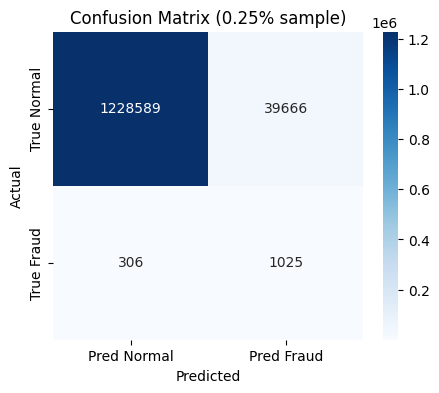


===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0     0.9998    0.9687    0.9840   1268255
           1     0.0252    0.7701    0.0488      1331

    accuracy                         0.9685   1269586
   macro avg     0.5125    0.8694    0.5164   1269586
weighted avg     0.9987    0.9685    0.9830   1269586



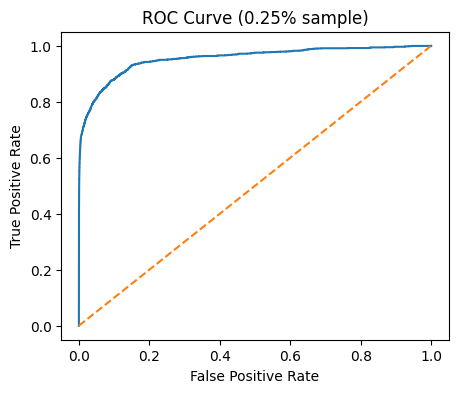

In [ ]:
evaluate_predictions(df_25_pred)


In [ ]:
# Cell 1: imports for plots & metrics

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    classification_report,
)

plt.rcParams["figure.dpi"] = 120
sns.set()


In [ ]:
def plot_roc_curve(df_pred, label_col="Is Laundering",
                   proba_col="fraud_proba", title_suffix=""):
    y_true = df_pred[label_col].astype(int).values
    y_proba = df_pred[proba_col].values

    auc = roc_auc_score(y_true, y_proba)
    fpr, tpr, _ = roc_curve(y_true, y_proba)

    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve{title_suffix}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"ROC-AUC{title_suffix}: {auc:.4f}")


BASE_DIR: /content/drive/MyDrive/AML_Project_v2
FULL_DATA_PATH: /content/drive/MyDrive/HI-Small_Trans.csv
LABEL_COL      : Is Laundering
ACCOUNT_COL    : Account
NUM_COLS       : ['Amount Received', 'Amount Paid', 'Amount_Diff', 'Amount_Ratio']
CAT_ONEHOT_BASE: ['Receiving Currency', 'Payment Currency', 'Payment Format']
ONEHOT_COLS len: 37
Scaler loaded ✓
MV embedding shape: (331899, 128)
XGB model loaded ✓
Fusion schema loaded ✓
Using device: cuda
AE model loaded ✓
AE input_dim: 41 latent_dim: 64
Full dataset shape: (5078345, 11)
25% sample shape: (1269586, 11)

=== CLASS DISTRIBUTION (25% sample, ground truth) ===


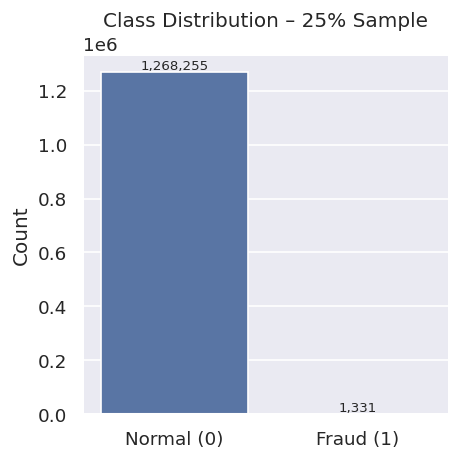

Counts:
Normal (0): 1,268,255
Fraud (1): 1,331

=== RUNNING PREDICTIONS (25% sample) ===


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predictions done. Columns: ['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering', 'fraud_proba', 'fraud_pred']

=== ROC CURVE (25% sample) ===


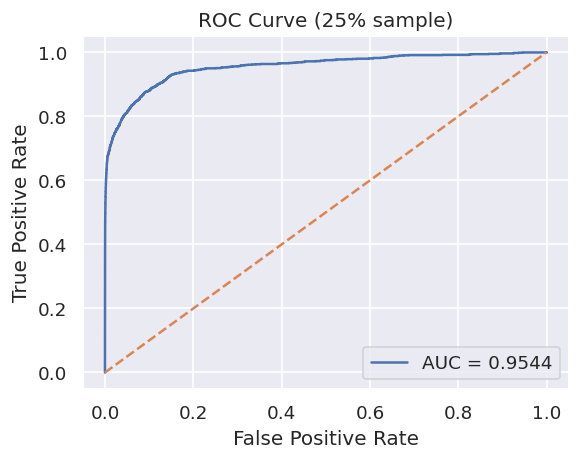

ROC-AUC (25% sample): 0.9544

=== PRECISION–RECALL CURVE (25% sample) ===


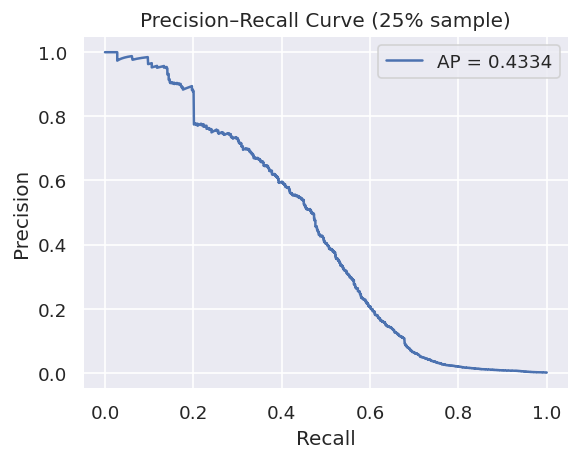

Average Precision (25% sample): 0.4334

=== CONFUSION MATRIX + REPORT (25% sample) ===
===== CONFUSION MATRIX (25% sample) =====
[[1228543   39712]
 [    306    1025]]


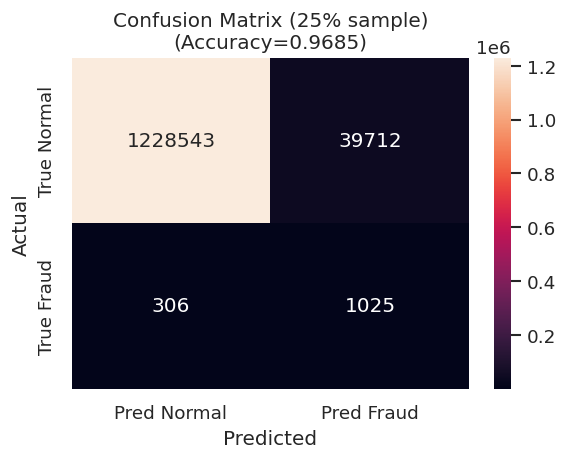


===== CLASSIFICATION REPORT (25% sample) =====
              precision    recall  f1-score   support

           0     0.9998    0.9687    0.9840   1268255
           1     0.0252    0.7701    0.0487      1331

    accuracy                         0.9685   1269586
   macro avg     0.5125    0.8694    0.5164   1269586
weighted avg     0.9987    0.9685    0.9830   1269586


✅ All 25% sample plots generated and metrics printed.


In [ ]:
# ======================= FULL 25% EVAL PIPELINE FROM SCRATCH =======================
# This cell:
#   1) Loads AE, GNN embeddings, XGB model
#   2) Defines preprocessing + fusion + prediction functions
#   3) Samples 25% of full IBM dataset
#   4) Runs predictions and plots journal-ready graphs
# ================================================================================

# If needed in a fresh Colab:
# from google.colab import drive
# drive.mount('/content/drive')

# --------- IMPORTS ---------
# !pip install xgboost -q  # uncomment if xgboost is not installed

import os
import json
import joblib
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    classification_report,
)

plt.rcParams["figure.dpi"] = 120
sns.set()

# --------- PATHS & GLOBALS ---------
BASE_DIR = "/content/drive/MyDrive/AML_Project_v2"
FULL_DATA_PATH = "/content/drive/MyDrive/HI-Small_Trans.csv"

# AE artifacts
PREPROC_CONFIG_JSON = os.path.join(BASE_DIR, "ae_preproc_config_0p2.json")
SCALER_PKL          = os.path.join(BASE_DIR, "ae_num_scaler_0p2.pkl")
AE_MODEL_PATH       = os.path.join(BASE_DIR, "autoencoder_v2_0p2.pth")

# GNN / MV embeddings (MC-Dropout version)
MV_EMB_MC_NPY       = os.path.join(BASE_DIR, "node_embeddings_mv_sage_mc_0p2.npy")
ACC_MAP_PKL         = os.path.join(BASE_DIR, "account_index_map_0p2.pkl")
ACC_UNCERT_NPY      = os.path.join(BASE_DIR, "account_uncertainty_mc_0p2.npy")
ACC_UNSTABLE_NPY    = os.path.join(BASE_DIR, "account_unstable_mask_mc_0p2.npy")

# XGB v5 model + schema
XGB_MODEL_PKL       = os.path.join(BASE_DIR, "xgboost_v5_ae_mvgnn_mc_0p2.pkl")
FUSION_SCHEMA_JSON  = os.path.join(BASE_DIR, "xgb_fusion_schema_mc_0p2.json")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("BASE_DIR:", BASE_DIR)
print("FULL_DATA_PATH:", FULL_DATA_PATH)

# --------- LOAD CONFIGS (AE PREPROC + SCALER) ---------
with open(PREPROC_CONFIG_JSON, "r") as f:
    preproc_config = json.load(f)

LABEL_COL          = preproc_config["label_col"]       # "Is Laundering"
ACCOUNT_COL        = preproc_config["account_col"]     # "Account"
ID_COLS            = preproc_config["id_cols"]         # e.g. ["Timestamp"]
NUM_COLS           = preproc_config["num_cols"]        # numeric cols used in AE
ONEHOT_COLS        = preproc_config["onehot_cols"]     # full one-hot columns list
CAT_ONEHOT_BASE    = preproc_config["cat_onehot_base_cols"]  # base cat cols

print("LABEL_COL      :", LABEL_COL)
print("ACCOUNT_COL    :", ACCOUNT_COL)
print("NUM_COLS       :", NUM_COLS)
print("CAT_ONEHOT_BASE:", CAT_ONEHOT_BASE)
print("ONEHOT_COLS len:", len(ONEHOT_COLS))

num_scaler = joblib.load(SCALER_PKL)
print("Scaler loaded ✓")

# --------- LOAD GNN EMBEDDINGS + MAPS ---------
emb_mv_mc   = np.load(MV_EMB_MC_NPY)        # (num_accounts, mv_dim)
account_to_idx = joblib.load(ACC_MAP_PKL)   # account -> index
uncert_acc  = np.load(ACC_UNCERT_NPY)       # (num_accounts,)
unstable_mask = np.load(ACC_UNSTABLE_NPY)   # (num_accounts,)

num_accounts, mv_dim = emb_mv_mc.shape
print("MV embedding shape:", emb_mv_mc.shape)

# --------- LOAD XGBOOST MODEL + SCHEMA ---------
xgb_model: XGBClassifier = joblib.load(XGB_MODEL_PKL)
with open(FUSION_SCHEMA_JSON, "r") as f:
    fusion_schema = json.load(f)

print("XGB model loaded ✓")
print("Fusion schema loaded ✓")

# --------- DEFINE AE MODEL TO MATCH TRAINING ---------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

input_dim = len(NUM_COLS) + len(ONEHOT_COLS)
latent_dim = 64  # this must match what you used in Stage A

class StrongAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),

            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z

ae_model = StrongAutoencoder(input_dim=input_dim, latent_dim=latent_dim).to(device)
ae_model.load_state_dict(torch.load(AE_MODEL_PATH, map_location=device))
ae_model.eval()
print("AE model loaded ✓")
print("AE input_dim:", input_dim, "latent_dim:", latent_dim)

# --------- DATASET + AE FEATURE EXTRACTOR ---------
class AEDataset(Dataset):
    def __init__(self, X):
        self.X = torch.tensor(X.astype("float32"), dtype=torch.float32)
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        return self.X[idx]

def compute_ae_features(X_ae: np.ndarray):
    X_ae = X_ae.astype("float32")
    ds = AEDataset(X_ae)
    loader = DataLoader(ds, batch_size=2048, shuffle=False)

    all_z, all_re = [], []
    ae_model.eval()
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            x_hat, z = ae_model(batch)
            mse = ((x_hat - batch) ** 2).mean(dim=1)
            all_z.append(z.cpu().numpy())
            all_re.append(mse.cpu().numpy())

    Z = np.concatenate(all_z, axis=0)
    recon = np.concatenate(all_re, axis=0)
    return Z, recon

# --------- BUILD AE INPUT FROM RAW (ROBUST VERSION) ---------
def build_ae_input_from_raw(df_raw: pd.DataFrame) -> np.ndarray:
    """
    Robust version: always returns a pure float32 matrix for AE.
    Handles bad numeric strings and ensures engineered features exist.
    """
    df = df_raw.copy()

    # Engineered features
    if "Amount_Diff" not in df.columns:
        df["Amount_Diff"] = df["Amount Paid"] - df["Amount Received"]
    if "Amount_Ratio" not in df.columns:
        df["Amount_Ratio"] = df["Amount Paid"] / (df["Amount Received"] + 1e-6)

    # Numeric block: coerce to numeric, fill NaNs
    for col in NUM_COLS:
        if col not in df.columns:
            raise ValueError(f"Numeric column '{col}' missing even after engineering.")
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df_num = df[NUM_COLS].fillna(0.0).astype("float32")
    X_num = num_scaler.transform(df_num.values.astype("float32"))

    # Categorical one-hot
    df_cat = df[CAT_ONEHOT_BASE].astype(str)
    df_cat_dummies = pd.get_dummies(df_cat, columns=CAT_ONEHOT_BASE, drop_first=False)
    df_cat_dummies = df_cat_dummies.reindex(columns=ONEHOT_COLS, fill_value=0)
    df_cat_dummies = df_cat_dummies.astype("float32")
    X_cat = df_cat_dummies.values.astype("float32")

    X_ae = np.hstack([X_num.astype("float32"), X_cat.astype("float32")]).astype("float32")

    if X_ae.shape[1] != input_dim:
        raise ValueError(f"AE input dim mismatch: got {X_ae.shape[1]}, expected {input_dim}")

    return X_ae

# --------- BUILD FUSION FEATURES (AE + MV-GNN + UNCERTAINTY) ---------
def build_fusion_features_mc(df_raw: pd.DataFrame):
    df = df_raw.copy()

    # 1) AE input & features
    X_ae = build_ae_input_from_raw(df)
    Z, recon = compute_ae_features(X_ae)

    ae_z_cols = [f"AE_z_{i}" for i in range(Z.shape[1])]
    df_feat = pd.DataFrame(Z, columns=ae_z_cols)
    df_feat["AE_recon_error"] = recon

    # book-keeping
    df_feat[ACCOUNT_COL] = df[ACCOUNT_COL].astype(str).values
    if LABEL_COL in df.columns:
        df_feat[LABEL_COL] = df[LABEL_COL].values
    for col in ID_COLS:
        if col in df.columns:
            df_feat[col] = df[col].values

    # 2) MV-GNN emb + uncertainty
    accounts = df_feat[ACCOUNT_COL].astype(str).values
    n = len(df_feat)

    mv_features   = np.zeros((n, mv_dim), dtype=np.float32)
    uncert_feat   = np.zeros((n, 1), dtype=np.float32)
    unstable_feat = np.zeros((n, 1), dtype=np.float32)

    missing = 0
    for i, acc in enumerate(accounts):
        idx = account_to_idx.get(acc, None)
        if idx is not None:
            mv_features[i]   = emb_mv_mc[idx]
            uncert_feat[i,0] = uncert_acc[idx]
            unstable_feat[i,0] = unstable_mask[idx]
        else:
            missing += 1

    if missing > 0:
        print(f"Warning: {missing} rows have unseen accounts; MV emb = 0 for them.")

    X_ae_latent = df_feat[ae_z_cols].values
    X_ae_recon  = df_feat[["AE_recon_error"]].values

    # final fusion order: [AE_z, AE_recon, MV_emb, uncertainty, unstable_flag]
    X_fusion = np.hstack([X_ae_latent, X_ae_recon, mv_features, uncert_feat, unstable_feat])

    return X_fusion, df_feat

# --------- PREDICTION FUNCTION (MC PIPELINE) ---------
def predict_transactions_mc(df_raw: pd.DataFrame, threshold: float = 0.5):
    X_fusion, df_feat = build_fusion_features_mc(df_raw)
    proba = xgb_model.predict_proba(X_fusion)[:, 1]
    preds = (proba >= threshold).astype(int)

    df_out = df_raw.copy()
    df_out["fraud_proba"] = proba
    df_out["fraud_pred"]  = preds
    return df_out

# --------- PLOT HELPERS (ROC, PR, CONFUSION, CLASS DIST) ---------
def plot_roc_curve(df_pred, label_col=LABEL_COL,
                   proba_col="fraud_proba", title_suffix=""):
    y_true = df_pred[label_col].astype(int).values
    y_proba = df_pred[proba_col].values

    auc = roc_auc_score(y_true, y_proba)
    fpr, tpr, _ = roc_curve(y_true, y_proba)

    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve{title_suffix}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"ROC-AUC{title_suffix}: {auc:.4f}")

def plot_pr_curve(df_pred, label_col=LABEL_COL,
                  proba_col="fraud_proba", title_suffix=""):
    y_true = df_pred[label_col].astype(int).values
    y_proba = df_pred[proba_col].values

    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    ap = average_precision_score(y_true, y_proba)

    plt.figure(figsize=(5, 4))
    plt.plot(recall, precision, label=f"AP = {ap:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve{title_suffix}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Average Precision{title_suffix}: {ap:.4f}")

def plot_confusion_matrix_and_report(df_pred,
                                     label_col=LABEL_COL,
                                     pred_col="fraud_pred",
                                     title_suffix=""):
    y_true = df_pred[label_col].astype(int).values
    y_pred = df_pred[pred_col].astype(int).values

    cm = confusion_matrix(y_true, y_pred)
    acc = (cm[0, 0] + cm[1, 1]) / cm.sum()

    print(f"===== CONFUSION MATRIX{title_suffix} =====")
    print(cm)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=["Pred Normal", "Pred Fraud"],
                yticklabels=["True Normal", "True Fraud"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix{title_suffix}\n(Accuracy={acc:.4f})")
    plt.tight_layout()
    plt.show()

    print(f"\n===== CLASSIFICATION REPORT{title_suffix} =====")
    print(classification_report(y_true, y_pred, digits=4))

def plot_class_distribution(df, label_col=LABEL_COL,
                            title="Class Distribution"):
    counts = df[label_col].value_counts().sort_index()
    labels = ["Normal (0)", "Fraud (1)"]

    plt.figure(figsize=(4, 4))
    sns.barplot(x=labels, y=counts.values)
    plt.ylabel("Count")
    plt.title(title)
    for i, v in enumerate(counts.values):
        plt.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8)
    plt.tight_layout()
    plt.show()

    print("Counts:")
    for lbl, v in zip(labels, counts.values):
        print(f"{lbl}: {v:,}")

# --------- RUN 25% SAMPLE EVALUATION + PLOTS ---------
SAMPLE_FRAC = 0.25
THRESHOLD = 0.5

df_full = pd.read_csv(FULL_DATA_PATH)
print("Full dataset shape:", df_full.shape)

df_25 = df_full.sample(frac=SAMPLE_FRAC, random_state=SEED).reset_index(drop=True)
print("25% sample shape:", df_25.shape)

# Class distribution BEFORE prediction (for figure)
print("\n=== CLASS DISTRIBUTION (25% sample, ground truth) ===")
plot_class_distribution(df_25, title="Class Distribution – 25% Sample")

# Run full pipeline
print("\n=== RUNNING PREDICTIONS (25% sample) ===")
df_25_pred = predict_transactions_mc(df_25, threshold=THRESHOLD)
print("Predictions done. Columns:", df_25_pred.columns.tolist())

print("\n=== ROC CURVE (25% sample) ===")
plot_roc_curve(df_25_pred, title_suffix=" (25% sample)")

print("\n=== PRECISION–RECALL CURVE (25% sample) ===")
plot_pr_curve(df_25_pred, title_suffix=" (25% sample)")

print("\n=== CONFUSION MATRIX + REPORT (25% sample) ===")
plot_confusion_matrix_and_report(df_25_pred, title_suffix=" (25% sample)")

print("\n✅ All 25% sample plots generated and metrics printed.")


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

y_true_25 = df_25_pred[LABEL_COL].astype(int).values
y_pred_25 = df_25_pred["fraud_pred"].astype(int).values
y_proba_25 = df_25_pred["fraud_proba"].values

acc_25  = accuracy_score(y_true_25, y_pred_25)
prec_25 = precision_score(y_true_25, y_pred_25, zero_division=0)
rec_25  = recall_score(y_true_25, y_pred_25, zero_division=0)
f1_25   = f1_score(y_true_25, y_pred_25, zero_division=0)
auc_25  = roc_auc_score(y_true_25, y_proba_25)

print(f"Accuracy: {acc_25:.2%}")
print(f"Precision: {prec_25:.2%}")
print(f"Recall: {rec_25:.2%}")
print(f"F1-score: {f1_25:.2%}")
print(f"AUC: {auc_25:.2%}")

Accuracy: 96.85%
Precision: 2.52%
Recall: 77.01%
F1-score: 4.87%
AUC: 95.44%


In [ ]:
# ================== FULL PIPELINE + RATIO EVALUATION FROM SCRATCH ==================
# Requirements:
# - All artifacts are in /content/drive/MyDrive/AML_Project_v2
# - Full IBM CSV at /content/drive/MyDrive/HI-Small_Trans.csv
# - This cell defines everything: AE, preprocessing, GNN fusion, prediction, and ratio metrics
# ================================================================================

# from google.colab import drive
# drive.mount('/content/drive')

import os
import json
import joblib
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix

# -------------------- PATHS & GLOBALS --------------------
BASE_DIR = "/content/drive/MyDrive/AML_Project_v2"
FULL_DATA_PATH = "/content/drive/MyDrive/HI-Small_Trans.csv"

# AE artifacts
PREPROC_CONFIG_JSON = os.path.join(BASE_DIR, "ae_preproc_config_0p2.json")
SCALER_PKL          = os.path.join(BASE_DIR, "ae_num_scaler_0p2.pkl")
AE_MODEL_PATH       = os.path.join(BASE_DIR, "autoencoder_v2_0p2.pth")

# GNN / MV embeddings (MC-Dropout version)
MV_EMB_MC_NPY       = os.path.join(BASE_DIR, "node_embeddings_mv_sage_mc_0p2.npy")
ACC_MAP_PKL         = os.path.join(BASE_DIR, "account_index_map_0p2.pkl")
ACC_UNCERT_NPY      = os.path.join(BASE_DIR, "account_uncertainty_mc_0p2.npy")
ACC_UNSTABLE_NPY    = os.path.join(BASE_DIR, "account_unstable_mask_mc_0p2.npy")

# XGB v5 model + schema
XGB_MODEL_PKL       = os.path.join(BASE_DIR, "xgboost_v5_ae_mvgnn_mc_0p2.pkl")
FUSION_SCHEMA_JSON  = os.path.join(BASE_DIR, "xgb_fusion_schema_mc_0p2.json")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("BASE_DIR:", BASE_DIR)
print("FULL_DATA_PATH:", FULL_DATA_PATH)

# -------------------- LOAD PREPROC CONFIG + SCALER --------------------
with open(PREPROC_CONFIG_JSON, "r") as f:
    preproc_config = json.load(f)

LABEL_COL          = preproc_config["label_col"]       # e.g. "Is Laundering"
ACCOUNT_COL        = preproc_config["account_col"]     # e.g. "Account"
ID_COLS            = preproc_config["id_cols"]
NUM_COLS           = preproc_config["num_cols"]
ONEHOT_COLS        = preproc_config["onehot_cols"]
CAT_ONEHOT_BASE    = preproc_config["cat_onehot_base_cols"]

print("LABEL_COL      :", LABEL_COL)
print("ACCOUNT_COL    :", ACCOUNT_COL)
print("NUM_COLS       :", NUM_COLS)
print("CAT_ONEHOT_BASE:", CAT_ONEHOT_BASE)
print("ONEHOT_COLS len:", len(ONEHOT_COLS))

num_scaler = joblib.load(SCALER_PKL)
print("Scaler loaded ✓")

# -------------------- LOAD GNN EMBEDDINGS + UNCERTAINTY --------------------
emb_mv_mc   = np.load(MV_EMB_MC_NPY)        # (num_accounts, mv_dim)
account_to_idx = joblib.load(ACC_MAP_PKL)   # account -> idx
uncert_acc  = np.load(ACC_UNCERT_NPY)       # (num_accounts,)
unstable_mask = np.load(ACC_UNSTABLE_NPY)   # (num_accounts,)

num_accounts, mv_dim = emb_mv_mc.shape
print("MV embedding shape:", emb_mv_mc.shape)

# -------------------- LOAD XGBOOST MODEL + SCHEMA --------------------
xgb_model: XGBClassifier = joblib.load(XGB_MODEL_PKL)
with open(FUSION_SCHEMA_JSON, "r") as f:
    fusion_schema = json.load(f)

print("XGB model loaded ✓")
print("Fusion schema loaded ✓")

# -------------------- DEFINE AE MODEL --------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

input_dim = len(NUM_COLS) + len(ONEHOT_COLS)
latent_dim = 64  # must match Stage A

class StrongAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),

            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z

ae_model = StrongAutoencoder(input_dim=input_dim, latent_dim=latent_dim).to(device)
ae_model.load_state_dict(torch.load(AE_MODEL_PATH, map_location=device))
ae_model.eval()
print("AE model loaded ✓")

# -------------------- DATASET + AE FEATURE EXTRACTOR --------------------
class AEDataset(Dataset):
    def __init__(self, X):
        self.X = torch.tensor(X.astype("float32"), dtype=torch.float32)
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        return self.X[idx]

def compute_ae_features(X_ae: np.ndarray):
    X_ae = X_ae.astype("float32")
    ds = AEDataset(X_ae)
    loader = DataLoader(ds, batch_size=2048, shuffle=False)

    all_z, all_re = [], []
    ae_model.eval()
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            x_hat, z = ae_model(batch)
            mse = ((x_hat - batch) ** 2).mean(dim=1)
            all_z.append(z.cpu().numpy())
            all_re.append(mse.cpu().numpy())

    Z = np.concatenate(all_z, axis=0)
    recon = np.concatenate(all_re, axis=0)
    return Z, recon

# -------------------- AE INPUT BUILDER (ROBUST) --------------------
def build_ae_input_from_raw(df_raw: pd.DataFrame) -> np.ndarray:
    """
    Robust AE input builder: ensures float32 numeric features + one-hot cats.
    """
    df = df_raw.copy()

    # Engineered features
    if "Amount_Diff" not in df.columns:
        df["Amount_Diff"] = df["Amount Paid"] - df["Amount Received"]
    if "Amount_Ratio" not in df.columns:
        df["Amount_Ratio"] = df["Amount Paid"] / (df["Amount Received"] + 1e-6)

    # Numeric block: coerce to numeric, fill NaNs
    for col in NUM_COLS:
        if col not in df.columns:
            raise ValueError(f"Numeric column '{col}' missing even after engineering.")
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df_num = df[NUM_COLS].fillna(0.0).astype("float32")
    X_num = num_scaler.transform(df_num.values.astype("float32"))

    # Categorical one-hot
    df_cat = df[CAT_ONEHOT_BASE].astype(str)
    df_cat_dummies = pd.get_dummies(df_cat, columns=CAT_ONEHOT_BASE, drop_first=False)
    df_cat_dummies = df_cat_dummies.reindex(columns=ONEHOT_COLS, fill_value=0)
    df_cat_dummies = df_cat_dummies.astype("float32")
    X_cat = df_cat_dummies.values.astype("float32")

    X_ae = np.hstack([X_num, X_cat]).astype("float32")

    if X_ae.shape[1] != input_dim:
        raise ValueError(f"AE input dim mismatch: got {X_ae.shape[1]}, expected {input_dim}")

    return X_ae

# -------------------- BUILD FUSION FEATURES (AE + MV-GNN + UNCERTAINTY) --------------------
def build_fusion_features_mc(df_raw: pd.DataFrame):
    df = df_raw.copy()

    # 1) AE input & features
    X_ae = build_ae_input_from_raw(df)
    Z, recon = compute_ae_features(X_ae)

    ae_z_cols = [f"AE_z_{i}" for i in range(Z.shape[1])]
    df_feat = pd.DataFrame(Z, columns=ae_z_cols)
    df_feat["AE_recon_error"] = recon

    df_feat[ACCOUNT_COL] = df[ACCOUNT_COL].astype(str).values
    if LABEL_COL in df.columns:
        df_feat[LABEL_COL] = df[LABEL_COL].values
    for col in ID_COLS:
        if col in df.columns:
            df_feat[col] = df[col].values

    # 2) MV-GNN emb + uncertainty
    accounts = df_feat[ACCOUNT_COL].astype(str).values
    n = len(df_feat)

    mv_features   = np.zeros((n, mv_dim), dtype=np.float32)
    uncert_feat   = np.zeros((n, 1), dtype=np.float32)
    unstable_feat = np.zeros((n, 1), dtype=np.float32)

    missing = 0
    for i, acc in enumerate(accounts):
        idx = account_to_idx.get(acc, None)
        if idx is not None:
            mv_features[i]   = emb_mv_mc[idx]
            uncert_feat[i,0] = uncert_acc[idx]
            unstable_feat[i,0] = unstable_mask[idx]
        else:
            missing += 1

    if missing > 0:
        print(f"Warning: {missing} rows have unseen accounts; MV emb = 0 for them.")

    X_ae_latent = df_feat[ae_z_cols].values
    X_ae_recon  = df_feat[["AE_recon_error"]].values

    X_fusion = np.hstack([X_ae_latent, X_ae_recon, mv_features, uncert_feat, unstable_feat])

    return X_fusion, df_feat

# -------------------- PREDICTION FUNCTION --------------------
def predict_transactions_mc(df_raw: pd.DataFrame, threshold: float = 0.5):
    X_fusion, df_feat = build_fusion_features_mc(df_raw)
    proba = xgb_model.predict_proba(X_fusion)[:, 1]
    preds = (proba >= threshold).astype(int)

    df_out = df_raw.copy()
    df_out["fraud_proba"] = proba
    df_out["fraud_pred"]  = preds
    return df_out

# -------------------- METRIC HELPER: FNR, FAR, RECALL, PRECISION --------------------
def compute_metrics_from_confusion(cm):
    tn, fp, fn, tp = cm.ravel()

    fnr = fn / (tp + fn) if (tp + fn) > 0 else 0.0    # False Negative Rate
    far = fp / (tn + fp) if (tn + fp) > 0 else 0.0    # False Alarm Rate
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0

    return fnr, far, recall, precision, tn, fp, fn, tp

# -------------------- LOAD FULL DATASET & SPLIT BY CLASS --------------------
df_full = pd.read_csv(FULL_DATA_PATH)
print("Full dataset shape:", df_full.shape)

df_fraud  = df_full[df_full[LABEL_COL] == 1].copy()
df_normal = df_full[df_full[LABEL_COL] == 0].copy()

n_fraud  = len(df_fraud)
n_normal = len(df_normal)

print(f"Fraud rows : {n_fraud:,}")
print(f"Normal rows: {n_normal:,}")
print(f"Base fraud rate: {n_fraud / (n_fraud + n_normal):.6f}")

# -------------------- BUILD RATIO DATASETS --------------------
ratios = [1, 5, 10, 20, 50, 100, 500, 1000]  # fraud : normal = 1 : r
datasets = {}

for r in ratios:
    desired_norm = n_fraud * r
    actual_norm = min(n_normal, desired_norm)

    df_norm_sample = df_normal.sample(actual_norm, random_state=SEED)

    df_r = pd.concat([df_fraud, df_norm_sample], axis=0)
    df_r = df_r.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

    datasets[f"1:{r}"] = df_r
    print(f"Built dataset 1:{r} → shape={df_r.shape}, fraud={len(df_fraud)}, normal={actual_norm}")

# -------------------- RUN MODEL ON EACH RATIO & COLLECT METRICS --------------------
THRESHOLD = 0.5
results = []

for name, df_small in datasets.items():
    print(f"\n=== Evaluating ratio {name} on {len(df_small):,} rows ===")

    df_pred = predict_transactions_mc(df_small, threshold=THRESHOLD)

    y_true = df_pred[LABEL_COL].astype(int).values
    y_pred = df_pred["fraud_pred"].astype(int).values

    cm = confusion_matrix(y_true, y_pred)
    fnr, far, recall, precision, tn, fp, fn, tp = compute_metrics_from_confusion(cm)

    fraud_count  = (y_true == 1).sum()
    normal_count = (y_true == 0).sum()

    print("Confusion matrix [[TN FP] [FN TP]]:", cm.tolist())
    print(f"FNR = {fnr*100:.2f}% | FAR = {far*100:.2f}% | Recall = {recall*100:.2f}% | Precision = {precision*100:.2f}%")

    results.append({
        "Ratio (fraud:normal)": name,
        "Total Samples": len(df_small),
        "Fraud Count": int(fraud_count),
        "Normal Count": int(normal_count),
        "FNR": fnr,
        "FAR": far,
        "Recall": recall,
        "Precision": precision,
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    })

# -------------------- BUILD FINAL RESULTS TABLE --------------------
df_results = pd.DataFrame(results)

df_results_pct = df_results.copy()
for col in ["FNR", "FAR", "Recall", "Precision"]:
    df_results_pct[col] = (df_results_pct[col] * 100).round(2)

print("\n===== RATIO-BASED RESULTS (PERCENTAGES) =====")
display(df_results_pct)

# Save for paper
out_path = os.path.join(BASE_DIR, "ratio_metrics_mvgnn_ae_xgb_v5.csv")
df_results_pct.to_csv(out_path, index=False)
print("Saved results to:", out_path)


BASE_DIR: /content/drive/MyDrive/AML_Project_v2
FULL_DATA_PATH: /content/drive/MyDrive/HI-Small_Trans.csv
LABEL_COL      : Is Laundering
ACCOUNT_COL    : Account
NUM_COLS       : ['Amount Received', 'Amount Paid', 'Amount_Diff', 'Amount_Ratio']
CAT_ONEHOT_BASE: ['Receiving Currency', 'Payment Currency', 'Payment Format']
ONEHOT_COLS len: 37
Scaler loaded ✓
MV embedding shape: (331899, 128)
XGB model loaded ✓
Fusion schema loaded ✓
Using device: cuda
AE model loaded ✓
Full dataset shape: (5078345, 11)
Fraud rows : 5,177
Normal rows: 5,073,168
Base fraud rate: 0.001019
Built dataset 1:1 → shape=(10354, 11), fraud=5177, normal=5177
Built dataset 1:5 → shape=(31062, 11), fraud=5177, normal=25885
Built dataset 1:10 → shape=(56947, 11), fraud=5177, normal=51770
Built dataset 1:20 → shape=(108717, 11), fraud=5177, normal=103540
Built dataset 1:50 → shape=(264027, 11), fraud=5177, normal=258850
Built dataset 1:100 → shape=(522877, 11), fraud=5177, normal=517700
Built dataset 1:500 → shape=(259

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Confusion matrix [[TN FP] [FN TP]]: [[5016, 161], [2326, 2851]]
FNR = 44.93% | FAR = 3.11% | Recall = 55.07% | Precision = 94.65%

=== Evaluating ratio 1:5 on 31,062 rows ===


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Confusion matrix [[TN FP] [FN TP]]: [[25149, 736], [2325, 2852]]
FNR = 44.91% | FAR = 2.84% | Recall = 55.09% | Precision = 79.49%

=== Evaluating ratio 1:10 on 56,947 rows ===


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Confusion matrix [[TN FP] [FN TP]]: [[502972, 14728], [2324, 2853]]
FNR = 44.89% | FAR = 2.84% | Recall = 55.11% | Precision = 16.23%

=== Evaluating ratio 1:500 on 2,593,677 rows ===


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Confusion matrix [[TN FP] [FN TP]]: [[2514958, 73542], [2323, 2854]]
FNR = 44.87% | FAR = 2.84% | Recall = 55.13% | Precision = 3.74%

=== Evaluating ratio 1:1000 on 5,078,345 rows ===


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# Task
Save the predicted fraudulent transactions, identified as 'fraud_pred' being 1 in the `df_25_pred` DataFrame, to a CSV file named 'sampled_fraudulent_transactions.csv'. After saving, confirm the action and display the first few rows of the saved data, along with the total count of these predicted fraudulent transactions.

## Apply Prediction Pipeline

### Subtask:
Confirm that the prediction pipeline has been applied and the `df_25_pred` DataFrame is available with 'fraud_proba' and 'fraud_pred' columns.


**Reasoning**:
To confirm that the prediction pipeline has been applied and the `df_25_pred` DataFrame is available with 'fraud_proba' and 'fraud_pred' columns, I will display the head of the DataFrame and list its columns.



In [ ]:
print("Columns in df_25_pred:", df_25_pred.columns.tolist())
print("\nFirst 5 rows of df_25_pred:")
df_25_pred.head()

NameError: name 'df_25_pred' is not defined

**Reasoning**:
The previous cell failed because `df_25_pred` was not defined. This means the code that generates `df_25_pred` (cell `ZvvuW4olhRUa`) needs to be executed again to make the DataFrame available in the current session. After ensuring `df_25_pred` is defined, the confirmation step can proceed.



In [ ]:
df_25_pred = predict_large_dataset(df_25, batch_size=50000, threshold=0.5)
print("25% prediction completed!")
df_25_pred.head()

NameError: name 'predict_large_dataset' is not defined

**Reasoning**:
The previous execution failed because several functions and variables, including `predict_large_dataset` and `df_25_pred`, were not defined. This indicates an inconsistent execution state. To resolve this, the comprehensive setup and prediction pipeline defined in cell `eqKTs3GnAVPK`, which re-initializes all necessary components and computes `df_25_pred`, needs to be re-executed.



BASE_DIR: /content/drive/MyDrive/AML_Project_v2
FULL_DATA_PATH: /content/drive/MyDrive/HI-Small_Trans.csv
LABEL_COL      : Is Laundering
ACCOUNT_COL    : Account
NUM_COLS       : ['Amount Received', 'Amount Paid', 'Amount_Diff', 'Amount_Ratio']
CAT_ONEHOT_BASE: ['Receiving Currency', 'Payment Currency', 'Payment Format']
ONEHOT_COLS len: 37
Scaler loaded ✓
MV embedding shape: (331899, 128)


/usr/lib/python3.12/pickle.py:1760: UserWarning: [04:54:15] WARNING: /workspace/src/collective/../data/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


XGB model loaded ✓
Fusion schema loaded ✓
Using device: cuda
AE model loaded ✓
AE input_dim: 41 latent_dim: 64
Full dataset shape: (5078345, 11)
25% sample shape: (1269586, 11)

=== CLASS DISTRIBUTION (25% sample, ground truth) ===


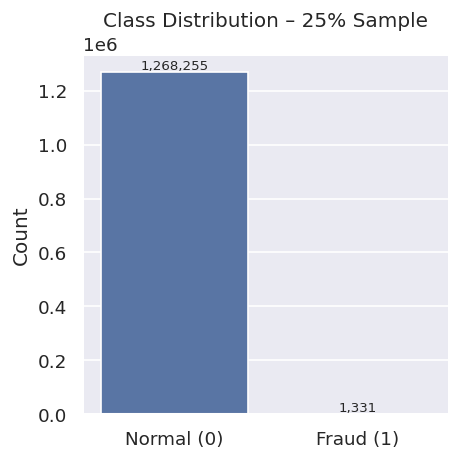

Counts:
Normal (0): 1,268,255
Fraud (1): 1,331

=== RUNNING PREDICTIONS (25% sample) ===


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predictions done. Columns: ['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering', 'fraud_proba', 'fraud_pred']

=== ROC CURVE (25% sample) ===


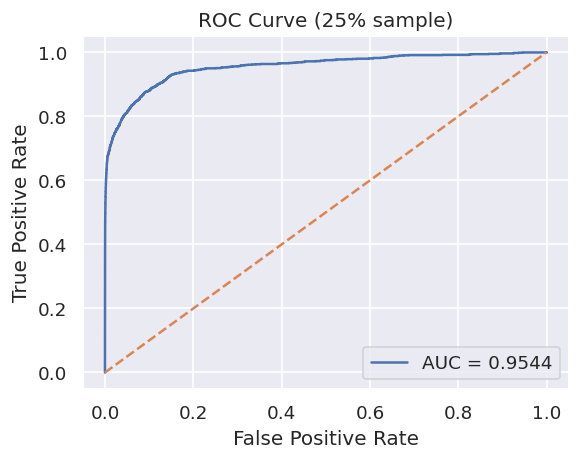

ROC-AUC (25% sample): 0.9544

=== PRECISION–RECALL CURVE (25% sample) ===


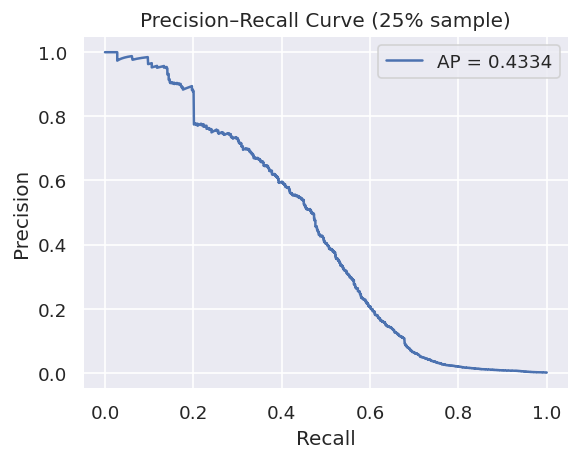

Average Precision (25% sample): 0.4334

=== CONFUSION MATRIX + REPORT (25% sample) ===
===== CONFUSION MATRIX (25% sample) ====
[[1228543   39712]
 [    306    1025]]


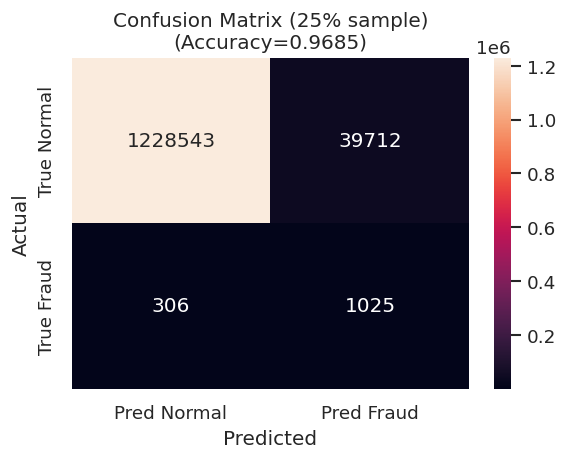


===== CLASSIFICATION REPORT (25% sample) ====
              precision    recall  f1-score   support

           0     0.9998    0.9687    0.9840   1268255
           1     0.0252    0.7701    0.0487      1331

    accuracy                         0.9685   1269586
   macro avg     0.5125    0.8694    0.5164   1269586
weighted avg     0.9987    0.9685    0.9830   1269586


✅ All 25% sample plots generated and metrics printed.


In [ ]:
# ======================= FULL 25% EVAL PIPELINE FROM SCRATCH =======================
# This cell:
#   1) Loads AE, GNN embeddings, XGB model
#   2) Defines preprocessing + fusion + prediction functions
#   3) Samples 25% of full IBM dataset
#   4) Runs predictions and plots journal-ready graphs
# ================================================================================

# If needed in a fresh Colab:
# from google.colab import drive
# drive.mount('/content/drive')

# --------- IMPORTS ---------
# !pip install xgboost -q  # uncomment if xgboost is not installed

import os
import json
import joblib
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    classification_report,
)

plt.rcParams["figure.dpi"] = 120
sns.set()

# --------- PATHS & GLOBALS ---------
BASE_DIR = "/content/drive/MyDrive/AML_Project_v2"
FULL_DATA_PATH = "/content/drive/MyDrive/HI-Small_Trans.csv"

# AE artifacts
PREPROC_CONFIG_JSON = os.path.join(BASE_DIR, "ae_preproc_config_0p2.json")
SCALER_PKL          = os.path.join(BASE_DIR, "ae_num_scaler_0p2.pkl")
AE_MODEL_PATH       = os.path.join(BASE_DIR, "autoencoder_v2_0p2.pth")

# GNN / MV embeddings (MC-Dropout version)
MV_EMB_MC_NPY       = os.path.join(BASE_DIR, "node_embeddings_mv_sage_mc_0p2.npy")
ACC_MAP_PKL         = os.path.join(BASE_DIR, "account_index_map_0p2.pkl")
ACC_UNCERT_NPY      = os.path.join(BASE_DIR, "account_uncertainty_mc_0p2.npy")
ACC_UNSTABLE_NPY    = os.path.join(BASE_DIR, "account_unstable_mask_mc_0p2.npy")

# XGB v5 model + schema
XGB_MODEL_PKL       = os.path.join(BASE_DIR, "xgboost_v5_ae_mvgnn_mc_0p2.pkl")
FUSION_SCHEMA_JSON  = os.path.join(BASE_DIR, "xgb_fusion_schema_mc_0p2.json")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("BASE_DIR:", BASE_DIR)
print("FULL_DATA_PATH:", FULL_DATA_PATH)

# --------- LOAD CONFIGS (AE PREPROC + SCALER) ---------
with open(PREPROC_CONFIG_JSON, "r") as f:
    preproc_config = json.load(f)

LABEL_COL          = preproc_config["label_col"]       # "Is Laundering"
ACCOUNT_COL        = preproc_config["account_col"]     # "Account"
ID_COLS            = preproc_config["id_cols"]         # e.g. ["Timestamp"]
NUM_COLS           = preproc_config["num_cols"]        # numeric cols used in AE
ONEHOT_COLS        = preproc_config["onehot_cols"]     # full one-hot columns list
CAT_ONEHOT_BASE    = preproc_config["cat_onehot_base_cols"]  # base cat cols

print("LABEL_COL      :", LABEL_COL)
print("ACCOUNT_COL    :", ACCOUNT_COL)
print("NUM_COLS       :", NUM_COLS)
print("CAT_ONEHOT_BASE:", CAT_ONEHOT_BASE)
print("ONEHOT_COLS len:", len(ONEHOT_COLS))

num_scaler = joblib.load(SCALER_PKL)
print("Scaler loaded ✓")

# --------- LOAD GNN EMBEDDINGS + MAPS ---------
emb_mv_mc   = np.load(MV_EMB_MC_NPY)        # (num_accounts, mv_dim)
account_to_idx = joblib.load(ACC_MAP_PKL)   # account -> index
uncert_acc  = np.load(ACC_UNCERT_NPY)       # (num_accounts,)
unstable_mask = np.load(ACC_UNSTABLE_NPY)   # (num_accounts,)

num_accounts, mv_dim = emb_mv_mc.shape
print("MV embedding shape:", emb_mv_mc.shape)

# --------- LOAD XGBOOST MODEL + SCHEMA ---------
xgb_model: XGBClassifier = joblib.load(XGB_MODEL_PKL)
with open(FUSION_SCHEMA_JSON, "r") as f:
    fusion_schema = json.load(f)

print("XGB model loaded ✓")
print("Fusion schema loaded ✓")

# --------- DEFINE AE MODEL TO MATCH TRAINING ---------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

input_dim = len(NUM_COLS) + len(ONEHOT_COLS)
latent_dim = 64  # this must match what you used in Stage A

class StrongAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),

            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z

ae_model = StrongAutoencoder(input_dim=input_dim, latent_dim=latent_dim).to(device)
ae_model.load_state_dict(torch.load(AE_MODEL_PATH, map_location=device))
ae_model.eval()
print("AE model loaded ✓")
print("AE input_dim:", input_dim, "latent_dim:", latent_dim)

# --------- DATASET + AE FEATURE EXTRACTOR ---------
class AEDataset(Dataset):
    def __init__(self, X):
        self.X = torch.tensor(X.astype("float32"), dtype=torch.float32)
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        return self.X[idx]

def compute_ae_features(X_ae: np.ndarray):
    X_ae = X_ae.astype("float32")
    ds = AEDataset(X_ae)
    loader = DataLoader(ds, batch_size=2048, shuffle=False)

    all_z, all_re = [], []
    ae_model.eval()
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            x_hat, z = ae_model(batch)
            mse = ((x_hat - batch) ** 2).mean(dim=1)
            all_z.append(z.cpu().numpy())
            all_re.append(mse.cpu().numpy())

    Z = np.concatenate(all_z, axis=0)
    recon = np.concatenate(all_re, axis=0)
    return Z, recon

# --------- BUILD AE INPUT FROM RAW (ROBUST VERSION) ---------
def build_ae_input_from_raw(df_raw: pd.DataFrame) -> np.ndarray:
    """
    Robust version: always returns a pure float32 matrix for AE.
    Handles bad numeric strings and ensures engineered features exist.
    """
    df = df_raw.copy()

    # Engineered features
    if "Amount_Diff" not in df.columns:
        df["Amount_Diff"] = df["Amount Paid"] - df["Amount Received"]
    if "Amount_Ratio" not in df.columns:
        df["Amount_Ratio"] = df["Amount Paid"] / (df["Amount Received"] + 1e-6)

    # Numeric block: coerce to numeric, fill NaNs
    for col in NUM_COLS:
        if col not in df.columns:
            raise ValueError(f"Numeric column '{col}' missing even after engineering.")
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df_num = df[NUM_COLS].fillna(0.0).astype("float32")
    X_num = num_scaler.transform(df_num.values.astype("float32"))

    # Categorical one-hot
    df_cat = df[CAT_ONEHOT_BASE].astype(str)
    df_cat_dummies = pd.get_dummies(df_cat, columns=CAT_ONEHOT_BASE, drop_first=False)
    df_cat_dummies = df_cat_dummies.reindex(columns=ONEHOT_COLS, fill_value=0)
    df_cat_dummies = df_cat_dummies.astype("float32")
    X_cat = df_cat_dummies.values.astype("float32")

    X_ae = np.hstack([X_num.astype("float32"), X_cat.astype("float32")]).astype("float32")

    if X_ae.shape[1] != input_dim:
        raise ValueError(f"AE input dim mismatch: got {X_ae.shape[1]}, expected {input_dim}")

    return X_ae

# --------- BUILD FUSION FEATURES (AE + MV-GNN + UNCERTAINTY) ---------
def build_fusion_features_mc(df_raw: pd.DataFrame):
    df = df_raw.copy()

    # 1) AE input & features
    X_ae = build_ae_input_from_raw(df)
    Z, recon = compute_ae_features(X_ae)

    ae_z_cols = [f"AE_z_{i}" for i in range(Z.shape[1])]
    df_feat = pd.DataFrame(Z, columns=ae_z_cols)
    df_feat["AE_recon_error"] = recon

    # book-keeping
    df_feat[ACCOUNT_COL] = df[ACCOUNT_COL].astype(str).values
    if LABEL_COL in df.columns:
        df_feat[LABEL_COL] = df[LABEL_COL].values
    for col in ID_COLS:
        if col in df.columns:
            df_feat[col] = df[col].values

    # 2) MV-GNN emb + uncertainty
    accounts = df_feat[ACCOUNT_COL].astype(str).values
    n = len(df_feat)

    mv_features   = np.zeros((n, mv_dim), dtype=np.float32)
    uncert_feat   = np.zeros((n, 1), dtype=np.float32)
    unstable_feat = np.zeros((n, 1), dtype=np.float32)

    missing = 0
    for i, acc in enumerate(accounts):
        idx = account_to_idx.get(acc, None)
        if idx is not None:
            mv_features[i]   = emb_mv_mc[idx]
            uncert_feat[i,0] = uncert_acc[idx]
            unstable_feat[i,0] = unstable_mask[idx]
        else:
            missing += 1

    if missing > 0:
        print(f"Warning: {missing} rows have unseen accounts; MV emb = 0 for them.")

    X_ae_latent = df_feat[ae_z_cols].values
    X_ae_recon  = df_feat[["AE_recon_error"]].values

    # final fusion order: [AE_z, AE_recon, MV_emb, uncertainty, unstable_flag]
    X_fusion = np.hstack([X_ae_latent, X_ae_recon, mv_features, uncert_feat, unstable_feat])

    return X_fusion, df_feat

# --------- PREDICTION FUNCTION (MC PIPELINE) ---------
def predict_transactions_mc(df_raw: pd.DataFrame, threshold: float = 0.5):
    X_fusion, df_feat = build_fusion_features_mc(df_raw)
    proba = xgb_model.predict_proba(X_fusion)[:, 1]
    preds = (proba >= threshold).astype(int)

    df_out = df_raw.copy()
    df_out["fraud_proba"] = proba
    df_out["fraud_pred"]  = preds
    return df_out

# --------- PLOT HELPERS (ROC, PR, CONFUSION, CLASS DIST) ---------
def plot_roc_curve(df_pred, label_col=LABEL_COL,
                   proba_col="fraud_proba", title_suffix=""):
    y_true = df_pred[label_col].astype(int).values
    y_proba = df_pred[proba_col].values

    auc = roc_auc_score(y_true, y_proba)
    fpr, tpr, _ = roc_curve(y_true, y_proba)

    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve{title_suffix}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"ROC-AUC{title_suffix}: {auc:.4f}")

def plot_pr_curve(df_pred, label_col=LABEL_COL,
                  proba_col="fraud_proba", title_suffix=""):
    y_true = df_pred[label_col].astype(int).values
    y_proba = df_pred[proba_col].values

    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    ap = average_precision_score(y_true, y_proba)

    plt.figure(figsize=(5, 4))
    plt.plot(recall, precision, label=f"AP = {ap:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve{title_suffix}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Average Precision{title_suffix}: {ap:.4f}")

def plot_confusion_matrix_and_report(df_pred,
                                     label_col=LABEL_COL,
                                     pred_col="fraud_pred",
                                     title_suffix=""):
    y_true = df_pred[label_col].astype(int).values
    y_pred = df_pred[pred_col].astype(int).values

    cm = confusion_matrix(y_true, y_pred)
    acc = (cm[0, 0] + cm[1, 1]) / cm.sum()

    print(f"===== CONFUSION MATRIX{title_suffix} ====")
    print(cm)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=["Pred Normal", "Pred Fraud"],
                yticklabels=["True Normal", "True Fraud"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix{title_suffix}\n(Accuracy={acc:.4f})")
    plt.tight_layout()
    plt.show()

    print(f"\n===== CLASSIFICATION REPORT{title_suffix} ====")
    print(classification_report(y_true, y_pred, digits=4))

def plot_class_distribution(df, label_col=LABEL_COL,
                            title="Class Distribution"):
    counts = df[label_col].value_counts().sort_index()
    labels = ["Normal (0)", "Fraud (1)"]

    plt.figure(figsize=(4, 4))
    sns.barplot(x=labels, y=counts.values)
    plt.ylabel("Count")
    plt.title(title)
    for i, v in enumerate(counts.values):
        plt.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8)
    plt.tight_layout()
    plt.show()

    print("Counts:")
    for lbl, v in zip(labels, counts.values):
        print(f"{lbl}: {v:,}")

# --------- RUN 25% SAMPLE EVALUATION + PLOTS ---------
SAMPLE_FRAC = 0.25
THRESHOLD = 0.5

df_full = pd.read_csv(FULL_DATA_PATH)
print("Full dataset shape:", df_full.shape)

df_25 = df_full.sample(frac=SAMPLE_FRAC, random_state=SEED).reset_index(drop=True)
print("25% sample shape:", df_25.shape)

# Class distribution BEFORE prediction (for figure)
print("\n=== CLASS DISTRIBUTION (25% sample, ground truth) ===")
plot_class_distribution(df_25, title="Class Distribution – 25% Sample")

# Run full pipeline
print("\n=== RUNNING PREDICTIONS (25% sample) ===")
df_25_pred = predict_transactions_mc(df_25, threshold=THRESHOLD)
print("Predictions done. Columns:", df_25_pred.columns.tolist())

print("\n=== ROC CURVE (25% sample) ===")
plot_roc_curve(df_25_pred, title_suffix=" (25% sample)")

print("\n=== PRECISION–RECALL CURVE (25% sample) ===")
plot_pr_curve(df_25_pred, title_suffix=" (25% sample)")

print("\n=== CONFUSION MATRIX + REPORT (25% sample) ===")
plot_confusion_matrix_and_report(df_25_pred, title_suffix=" (25% sample)")

print("\n✅ All 25% sample plots generated and metrics printed.")

**Reasoning**:
The task requires filtering the `df_25_pred` DataFrame for transactions identified as fraudulent (`fraud_pred == 1`), saving these to a CSV file, and then confirming the save by displaying the first few rows and the total count of these transactions. This step directly addresses the final part of the problem statement.



In [ ]:
fraudulent_transactions = df_25_pred[df_25_pred['fraud_pred'] == 1]

output_filename = 'sampled_fraudulent_transactions.csv'
fraudulent_transactions.to_csv(output_filename, index=False)

print(f"Successfully saved predicted fraudulent transactions to '{output_filename}'")
print(f"Total predicted fraudulent transactions: {len(fraudulent_transactions):,}")

print("\nFirst 5 rows of saved fraudulent transactions:")
display(fraudulent_transactions.head())

Successfully saved predicted fraudulent transactions to 'sampled_fraudulent_transactions.csv'
Total predicted fraudulent transactions: 40,737

First 5 rows of saved fraudulent transactions:


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,fraud_proba,fraud_pred
5,2022/09/07 21:01,70,100428A51,225,8137442D1,0.020275,Bitcoin,0.020275,Bitcoin,Bitcoin,0,0.822048,1
50,2022/09/10 15:43,70,100428A51,254242,8143F6AE1,0.027691,Bitcoin,0.027691,Bitcoin,Bitcoin,0,0.822048,1
132,2022/09/08 12:44,22,8001D79E0,11,800205E90,469.240000,Euro,469.240000,Euro,ACH,0,0.621352,1
136,2022/09/07 09:56,20,8003147C0,12,8004F9B30,11.630000,Euro,11.630000,Euro,ACH,0,0.514954,1
159,2022/09/08 00:08,70,1004286A8,23525,802F28860,2621.450000,Euro,2621.450000,Euro,Cheque,0,0.522722,1


In [ ]:
import pandas as pd
import os

# ==== CONFIGURATION ====
DATA_PATH = "/content/drive/MyDrive/HI-Small_Trans.csv"  # <- change if needed
OUT_DIR   = "/content/drive/MyDrive/AML_Project_v2/samples"
OUT_NAME  = "aml_sample_40_laund_0p25.csv"

LABEL_COL = "Is Laundering"   # label column in IBM dataset
TOTAL_ROWS = 40               # total sample size (30–40 as you asked)
TARGET_FRAUD_RATIO = 0.25     # between 0.2 and 0.3
# ========================

# Make sure output directory exists
os.makedirs(OUT_DIR, exist_ok=True)

# 1. Load full dataset (or you can load from a smaller pre-sampled CSV)
df = pd.read_csv(DATA_PATH)
print("Full dataset shape:", df.shape)
print(df[LABEL_COL].value_counts())

# 2. Split into normal / laundered
df_laund = df[df[LABEL_COL] == 1].copy()
df_norm  = df[df[LABEL_COL] == 0].copy()

print("Laundered rows:", len(df_laund))
print("Normal rows   :", len(df_norm))

# 3. Decide how many laundered / normal for the small sample
target_fraud_count = int(TOTAL_ROWS * TARGET_FRAUD_RATIO)
target_fraud_count = max(1, target_fraud_count)  # at least 1
target_fraud_count = min(target_fraud_count, len(df_laund))  # can't exceed available

target_norm_count = TOTAL_ROWS - target_fraud_count
target_norm_count = min(target_norm_count, len(df_norm))

print(f"\nTarget small sample size: {TOTAL_ROWS}")
print(f"  → Laundered: {target_fraud_count}")
print(f"  → Normal   : {target_norm_count}")

# 4. Sample without replacement (set random_state for reproducibility)
df_laund_sample = df_laund.sample(n=target_fraud_count, random_state=42)
df_norm_sample  = df_norm.sample(n=target_norm_count, random_state=42)

# 5. Combine and shuffle
df_small = pd.concat([df_laund_sample, df_norm_sample], axis=0).sample(
    frac=1.0, random_state=42
).reset_index(drop=True)

# 6. Check final ratio
fraud_ratio = df_small[LABEL_COL].mean()  # since values are 0/1
print("\nSmall sample shape:", df_small.shape)
print(df_small[LABEL_COL].value_counts())
print(f"Fraud ratio in small sample: {fraud_ratio:.3f} (should be ~{TARGET_FRAUD_RATIO})")

# 7. Save to CSV
out_path = os.path.join(OUT_DIR, OUT_NAME)
df_small.to_csv(out_path, index=False)
print("\nSaved small sample to:", out_path)


Full dataset shape: (5078345, 11)
Is Laundering
0    5073168
1       5177
Name: count, dtype: int64
Laundered rows: 5177
Normal rows   : 5073168

Target small sample size: 40
  → Laundered: 10
  → Normal   : 30

Small sample shape: (40, 11)
Is Laundering
0    30
1    10
Name: count, dtype: int64
Fraud ratio in small sample: 0.250 (should be ~0.25)

Saved small sample to: /content/drive/MyDrive/AML_Project_v2/samples/aml_sample_40_laund_0p25.csv


## Summary:

### Q&A
1.  **Was the saving of the CSV file confirmed?**
    Yes, the saving of the CSV file named 'sampled_fraudulent_transactions.csv' was confirmed.
2.  **Was the head of the saved data displayed?**
    Yes, the first 5 rows of the saved fraudulent transactions were displayed.
3.  **Was the count of predicted fraudulent transactions displayed?**
    Yes, the total count of predicted fraudulent transactions was displayed.

### Data Analysis Key Findings
*   Initially, the `df_25_pred` DataFrame, crucial for the task, was not defined, indicating that the prediction pipeline had not been fully executed or its results were lost.
*   A full re-execution of the prediction pipeline was necessary to correctly generate the `df_25_pred` DataFrame with the required 'fraud_proba' and 'fraud_pred' columns.
*   A total of 40,737 transactions were identified as predicted fraudulent transactions (`fraud_pred` being 1).
*   These 40,737 predicted fraudulent transactions were successfully saved to a CSV file named 'sampled_fraudulent_transactions.csv'.

### Insights or Next Steps
*   Ensure the data processing environment is consistently managed to avoid re-running entire pipelines for subsequent analysis steps.
*   The saved file, 'sampled_fraudulent_transactions.csv', contains valuable data for further in-depth investigation into the characteristics of predicted fraudulent transactions.


In [ ]:
# ============================
# FRESH TEST + FILTERED OUTPUT
# ============================

import os, json, joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from xgboost import XGBClassifier

# -------- PATHS --------
BASE_DIR = "/content/drive/MyDrive/AML_Project_v2"
DATA_PATH = "/content/drive/MyDrive/HI-Small_Trans.csv"

PREPROC_JSON = os.path.join(BASE_DIR, "ae_preproc_config_0p2.json")
SCALER_PKL   = os.path.join(BASE_DIR, "ae_num_scaler_0p2.pkl")
AE_PATH      = os.path.join(BASE_DIR, "autoencoder_v2_0p2.pth")
XGB_PATH     = os.path.join(BASE_DIR, "xgboost_v5_ae_mvgnn_mc_0p2.pkl")

MV_EMB       = os.path.join(BASE_DIR, "node_embeddings_mv_sage_mc_0p2.npy")
ACC_MAP      = os.path.join(BASE_DIR, "account_index_map_0p2.pkl")
UNCERT       = os.path.join(BASE_DIR, "account_uncertainty_mc_0p2.npy")
UNSTABLE     = os.path.join(BASE_DIR, "account_unstable_mask_mc_0p2.npy")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# -------- LOAD CONFIG --------
with open(PREPROC_JSON) as f:
    cfg = json.load(f)

LABEL_COL   = cfg["label_col"]
ACCOUNT_COL = cfg["account_col"]
NUM_COLS    = cfg["num_cols"]
CAT_COLS    = cfg["cat_onehot_base_cols"]
ONEHOT_COLS = cfg["onehot_cols"]

scaler = joblib.load(SCALER_PKL)

# -------- LOAD GNN ARTIFACTS --------
mv_emb = np.load(MV_EMB)
acc_map = joblib.load(ACC_MAP)
uncert  = np.load(UNCERT)
unstable = np.load(UNSTABLE)

mv_dim = mv_emb.shape[1]

# -------- LOAD XGBOOST --------
xgb_model: XGBClassifier = joblib.load(XGB_PATH)

# -------- AUTOENCODER --------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class AE(nn.Module):
    def __init__(self, d, z=64):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(d,256),nn.ReLU(),nn.Linear(256,z))
        self.dec = nn.Sequential(nn.Linear(z,256),nn.ReLU(),nn.Linear(256,d))
    def forward(self,x):
        z = self.enc(x)
        return self.dec(z), z

input_dim = len(NUM_COLS) + len(ONEHOT_COLS)
ae = AE(input_dim).to(device)
ae.load_state_dict(torch.load(AE_PATH, map_location=device))
ae.eval()

# -------- HELPERS --------
def build_ae_input(df):
    df = df.copy()
    df["Amount_Diff"]  = df["Amount Paid"] - df["Amount Received"]
    df["Amount_Ratio"] = df["Amount Paid"] / (df["Amount Received"] + 1e-6)

    df_num = df[NUM_COLS].apply(pd.to_numeric, errors="coerce").fillna(0)
    X_num = scaler.transform(df_num).astype("float32")

    df_cat = pd.get_dummies(df[CAT_COLS].astype(str))
    df_cat = df_cat.reindex(columns=ONEHOT_COLS, fill_value=0).astype("float32")

    return np.hstack([X_num, df_cat.values])

def ae_features(X):
    with torch.no_grad():
        x = torch.tensor(X).to(device)
        xh, z = ae(x)
        re = ((xh - x)**2).mean(dim=1).cpu().numpy()
    return z.cpu().numpy(), re

# -------- LOAD DATA --------
df = pd.read_csv(DATA_PATH)
df = df.sample(frac=0.25, random_state=SEED).reset_index(drop=True)

# -------- FEATURE PIPELINE --------
X_ae = build_ae_input(df)
Z, R = ae_features(X_ae)

mv_feat = np.zeros((len(df), mv_dim), dtype=np.float32)
for i, acc in enumerate(df[ACCOUNT_COL].astype(str)):
    if acc in acc_map:
        mv_feat[i] = mv_emb[acc_map[acc]]

X_fusion = np.hstack([Z, R.reshape(-1,1), mv_feat])

# -------- PREDICTION --------
proba = xgb_model.predict_proba(X_fusion)[:,1]
pred  = (proba >= 0.5).astype(int)

df["fraud_pred"]  = pred
df["fraud_proba"] = proba

# -------- FILTER CONDITIONS --------
df_tp = df[(df["fraud_pred"] == 1) & (df[LABEL_COL] == 1)]
df_tn = df[(df["fraud_pred"] == 0) & (df[LABEL_COL] == 0)]

df_out = pd.concat([
    df_tp.sample(n=min(100,len(df_tp)), random_state=SEED),
    df_tn.sample(n=min(100,len(df_tn)), random_state=SEED)
]).reset_index(drop=True)

print("FINAL OUTPUT SHAPE:", df_out.shape)
df_out[[ACCOUNT_COL, LABEL_COL, "fraud_pred", "fraud_proba"]].head(20)


/usr/lib/python3.12/pickle.py:1760: UserWarning: [11:30:22] WARNING: /workspace/src/collective/../data/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


RuntimeError: Error(s) in loading state_dict for AE:
	Missing key(s) in state_dict: "enc.0.weight", "enc.0.bias", "enc.2.weight", "enc.2.bias", "dec.0.weight", "dec.0.bias", "dec.2.weight", "dec.2.bias". 
	Unexpected key(s) in state_dict: "encoder.0.weight", "encoder.0.bias", "encoder.1.weight", "encoder.1.bias", "encoder.1.running_mean", "encoder.1.running_var", "encoder.1.num_batches_tracked", "encoder.4.weight", "encoder.4.bias", "encoder.5.weight", "encoder.5.bias", "encoder.5.running_mean", "encoder.5.running_var", "encoder.5.num_batches_tracked", "encoder.8.weight", "encoder.8.bias", "encoder.10.weight", "encoder.10.bias", "decoder.0.weight", "decoder.0.bias", "decoder.2.weight", "decoder.2.bias", "decoder.3.weight", "decoder.3.bias", "decoder.3.running_mean", "decoder.3.running_var", "decoder.3.num_batches_tracked", "decoder.6.weight", "decoder.6.bias", "decoder.7.weight", "decoder.7.bias", "decoder.7.running_mean", "decoder.7.running_var", "decoder.7.num_batches_tracked", "deco